<a href="https://colab.research.google.com/github/noor-gh06/Cybercrime-DataMining/blob/main/Final_phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import files
uploaded = files.upload()

Saving Cyber Crimes Dataset.csv to Cyber Crimes Dataset.csv


In [11]:
### Dataset Overview
#The dataset consists of 100,000 rows and 15 columns, indicating a large dataset with multiple features available for analysis.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#load dataset and preview structure

df = pd.read_csv("Cyber Crimes Dataset.csv", sep=";")
df.shape
df.head()
df.dtypes

,0
attack_type,object
target_system,object
outcome,object
timestamp,object
attacker_ip,object
target_ip,object
data_compromised_GB,float64
attack_duration_min,int64
security_tools_used,object
user_role,object


In [ ]:
df.info()
#show basic information about dataset

In [ ]:
df.describe()
#generate descriptive statistics for numeric columns


In [ ]:
df.describe().loc[['min', '25%', '50%', '75%', 'max']]
#display the five-number summary

In [13]:
# Select only numeric columns and compute the correlation matrix
corr = df.select_dtypes(include='number').corr()
corr

,data_compromised_GB,attack_duration_min,attack_severity,response_time_min
data_compromised_GB,1.000000,-0.000763,-0.001609,-0.001225
attack_duration_min,-0.000763,1.000000,-0.004516,-0.001168
attack_severity,-0.001609,-0.004516,1.000000,-0.004034
response_time_min,-0.001225,-0.001168,-0.004034,1.000000


A series of Exploratory Data Analysis (EDA) steps were performed to better understand the dataset.

First, numeric columns were identified and summarized using statistical measures.

Five-number summaries were computed to analyze data spread and detect potential outliers.

Correlation analysis was conducted to examine relationships between numerical features.

These steps provided insights into data distribution, skewness, and potential preprocessing needs.

In [12]:
#This code was used to extract only the numeric columns from the dataset, since statistical analysis and visualization techniques (such as outlier detection and plotting) require numerical data.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)

Numeric columns: ['data_compromised_GB', 'attack_duration_min', 'attack_severity', 'response_time_min']


In [15]:
#Missing Values Analysis
#This code was used to analyze missing values in the dataset by calculating both their count and percentage for each column. This helps in understanding their impact and deciding the appropriate data cleaning strategy.
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
}).sort_values("missing_count", ascending=False)

print(missing_summary)

                     missing_count  missing_percent
attack_type                      0              0.0
target_system                    0              0.0
outcome                          0              0.0
timestamp                        0              0.0
attacker_ip                      0              0.0
target_ip                        0              0.0
data_compromised_GB              0              0.0
attack_duration_min              0              0.0
security_tools_used              0              0.0
user_role                        0              0.0
location                         0              0.0
attack_severity                  0              0.0
industry                         0              0.0
response_time_min                0              0.0
mitigation_method                0              0.0


In [ ]:
# Missing Values Analysis
#This code checks whether missing values actually exist before creating any visualization. If missing values are found, a bar chart is generated to display their count per column, helping evaluate their impact and decide on appropriate data cleaning steps.
miss_only = missing_summary[missing_summary["missing_count"] > 0]

if miss_only.empty:
    print("No missing values found (0 missing). Therefore, no visualization is required.")
else:
    plt.figure(figsize=(10,4))
    plt.bar(miss_only.index.astype(str), miss_only["missing_count"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Missing Values Count per Column")
    plt.tight_layout()
    plt.show()

In [ ]:
#Skewness
#This code calculates the skewness of numeric columns to understand the distribution shape of the data. High skewness values indicate asymmetric distributions, which may require transformation or further preprocessing before analysis.
skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness values:")
print(skew_vals)

In [ ]:
#Histograms
#Histograms were used to visually display the distribution of each numeric column. This helps in understanding the data distribution, detecting skewness, and identifying potential outliers, supporting the skewness analysis results.
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

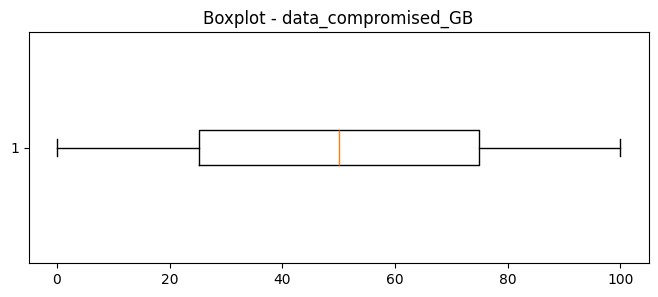

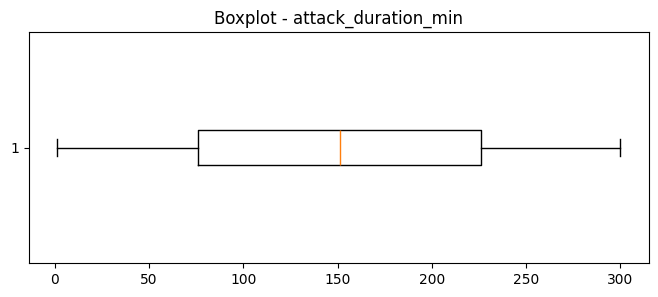

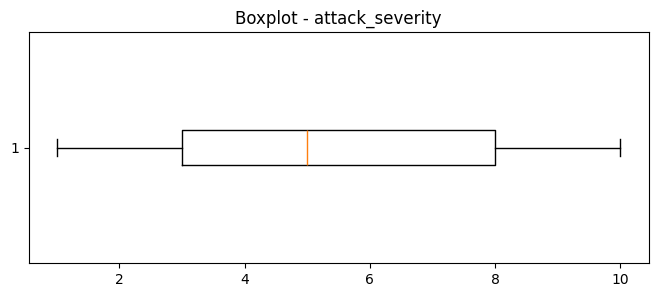

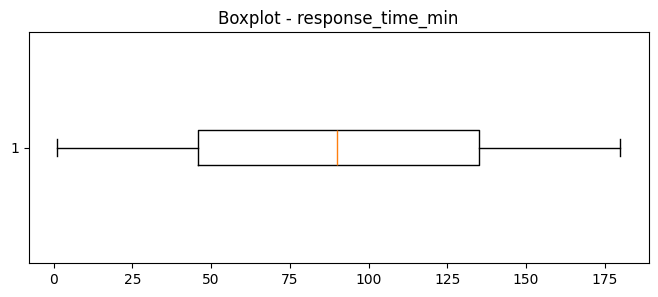

                column  outlier_count
0  data_compromised_GB              0
1  attack_duration_min              0
2      attack_severity              0
3    response_time_min              0


In [14]:
#Boxplots + Outliers (IQR Method)
#The IQR method was used to detect outliers in numeric columns by calculating Q1, Q3, and defining lower and upper bounds. Additionally, boxplots were generated to visually display the distribution and outliers. This analysis helps assess the impact of extreme values and decide whether further preprocessing is required.
def iqr_outliers_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    return outliers

outlier_report = []

for col in numeric_cols:
    plt.figure(figsize=(8,3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot - {col}")
    plt.show()

    outliers = iqr_outliers_count(df[col])
    outlier_report.append([col, outliers])

outlier_df = pd.DataFrame(outlier_report, columns=["column", "outlier_count"])
print(outlier_df.sort_values("outlier_count", ascending=False))

In [ ]:
#Scatter Plot
#A scatter plot was used to examine the relationship between attack severity and the amount of compromised data. This visualization helps identify potential correlations, patterns, and outliers that may impact the analysis.
plt.figure(figsize=(8,5))
plt.scatter(df["attack_severity"], df["data_compromised_GB"], alpha=0.2)
plt.title("Scatter Plot: attack_severity vs data_compromised_GB")
plt.xlabel("attack_severity")
plt.ylabel("data_compromised_GB")
plt.show()

In [ ]:
#Range Check
#This code calculates the minimum, maximum, and range of each numeric column to understand the value distribution and detect large scale differences between variables. This helps determine whether normalization or scaling is required before modeling.
range_data = []

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    range_val = max_val - min_val
    range_data.append([col, min_val, max_val, range_val])

range_df = pd.DataFrame(range_data, columns=["column", "min", "max", "range"])
print(range_df.sort_values("range", ascending=False))

A series of Exploratory Data Analysis (EDA) steps were performed to better understand the dataset before building any model.

First, numeric columns were identified since statistical analysis and visualization techniques require numerical data. Missing values were then analyzed by calculating their count and percentage per column, followed by conditional visualization to assess their impact.

Data distribution was examined using:

Skewness to measure distribution asymmetry.

Histograms to visualize distribution shapes.

Boxplots combined with the IQR method to detect and count outliers.

A scatter plot was used to explore the relationship between attack severity and compromised data, helping identify possible correlations or patterns.

Finally, the minimum, maximum, and range were calculated for each numeric column to detect scale differences and determine whether normalization might be required.

Overall, these steps provided a comprehensive understanding of the dataset, identified potential issues, and prepared the data for further preprocessing or modeling

In [ ]:
#Categorical Variables Distribution
#Creates bar charts to show how values are distributed in categorical features.
categorical_cols = ['attack_type','industry','location','security_tools_used']

for col in categorical_cols:
    plt.figure()
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
    plt.show()


**Attack Type Distribution**

The bar chart shows that cyber attack types such as phishing, DDoS, zero-day exploits, SQL injection, malware, ransomware, brute force, and cross-site scripting are distributed almost evenly.

This indicates that the dataset provides balanced representation across attack categories, allowing machine learning models to learn patterns without bias toward a specific attack type.

**Industry Distribution**

The distribution of incidents across industries (Energy, Retail, Finance, Healthcare, Technology, Education, Manufacturing, and Government) appears uniform.

This suggests that cybercrime incidents affect various sectors equally in the dataset, improving its representativeness and preventing sector-specific bias during model training.

**Location Distribution**

The dataset shows a balanced distribution across multiple countries including Australia, Brazil, Germany, Russia, UK, France, USA, Canada, China, and India.

This geographic diversity ensures that the dataset does not favor a specific region and improves the generalizability of the analysis.

**Security Tools Used Distribution**

Security tools such as Firewall, Endpoint Detection, MFA, VPN, Antivirus, WAF, SIEM, and IDS appear with similar frequencies.

This balanced representation enables fair analysis of different security measures and prevents overrepresentation of any specific defense mechanism.

In [ ]:
#Class Label Distribution (Outcome)
#Shows how the dataset is divided between Success and Failure.
plt.figure()
sns.countplot(data=df, x='outcome')
plt.title('Class Distribution')
plt.show()

In [ ]:
#Class Percentage Calculation
#Calculates the percentage of each class to confirm balance
class_percent = df['outcome'].value_counts(normalize=True)*100
print(class_percent)


The outcome variable is almost perfectly balanced:

Success: 50.03%

Failure: 49.97%

This indicates that the dataset does not suffer from class imbalance.

A balanced class distribution ensures that classification models will not be biased toward one outcome and can learn patterns from both classes effectively.

In [ ]:
#Attack Type vs Outcome Relationship
#Shows the relationship between attack types and outcomes.
plt.figure()
sns.countplot(data=df, x='attack_type', hue='outcome')
plt.xticks(rotation=45)
plt.title('Attack Type vs Outcome')
plt.show()

**Relationship Between Attack Type and Outcome**

The comparison between attack types and outcomes shows that both success and failure occur at similar rates across all attack categories.

This suggests that:

no single attack type guarantees success or failure,

attack outcomes are likely influenced by multiple factors,

the dataset is suitable for predictive modeling.

**Class Imbalance Evaluation**

Based on the visualizations and class proportions:

no significant class imbalance is present,

no rare categories were detected,

the dataset is suitable for classification tasks without resampling.


**Impact on Machine Learning Models**

Because the dataset is balanced and well distributed:

models are less likely to develop bias,

evaluation metrics such as accuracy will be reliable,

the model can learn patterns fairly across categories,

no balancing techniques (oversampling or undersampling) are required.


**Conclusion**

The categorical distributions and class label analysis indicate that the dataset is well balanced across attack types, industries, locations, security tools, and outcome classes. This balance supports reliable data mining and machine learning processes and improves the quality of predictive modeling in later phases.

In [ ]:

# Preprocessing
# 1) Timestamp -> Year / Month / Hour
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    df["year"] = df["timestamp"].dt.year
    df["month"] = df["timestamp"].dt.month
    df["hour"] = df["timestamp"].dt.hour

    df.drop(columns=["timestamp"], inplace=True)

    df["year"] = df["year"].fillna(df["year"].median())
    df["month"] = df["month"].fillna(df["month"].median())
    df["hour"] = df["hour"].fillna(df["hour"].median())

The timestamp column was converted into datetime format and split into year, month, and hour features. This allows the model to capture temporal patterns instead of treating the timestamp as raw text. Missing values were replaced using the median to ensure data completeness.

In [ ]:
# 2) Drop high-cardinality columns (IPs)
cols_to_drop = ["attacker_ip", "target_ip"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

The columns attacker_ip and target_ip were removed because they contain highly unique values. Such features increase dimensionality and may cause overfitting without adding meaningful predictive power.

In [ ]:
# 3) Encoding categorical variables (except target)
target_col = "outcome"
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c != target_col]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

Categorical variables (except the target column) were converted into numerical format using One-Hot Encoding. This transformation enables machine learning models to process categorical data effectively.

In [ ]:
# 4) Missing values check
missing_count = df_encoded.isnull().sum().sum()
print("Total missing values after preprocessing:", missing_count)

After preprocessing, missing values were checked to ensure data completeness. No missing values remained after imputation.

In [ ]:

# 5) Shape before/after + preview
print("Shape before preprocessing:", df.shape)
print("Shape after preprocessing:", df_encoded.shape)
df_encoded.head()

The dataset shape was compared before and after preprocessing. The increase in the number of columns is due to the application of One-Hot Encoding.

In [ ]:
# Save snapshot before scaling
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
df_before_scaling = df_encoded.copy()
print("Preview before scaling:")
display(df_before_scaling.head())

In [ ]:
# Apply Standardization to numeric features
from sklearn.preprocessing import StandardScaler

numeric_cols = df_encoded.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print("Preview after scaling:")
display(df_encoded.head())


In [ ]:
# Feature Selection
columns_to_drop = []
df_encoded = df_encoded.drop(columns=columns_to_drop, errors='ignore')
df_before_scaling = df_encoded.copy()

In [ ]:
# Compare shape before and after preprocessing
print("Shape before scaling:", df_before_scaling.shape)
print("Shape after preprocessing:", df_encoded.shape)



In [ ]:
# Save final processed dataset
df_encoded.to_csv("final_dataset.csv", index=False)
print("Final dataset saved successfully")